In [1]:
import numpy as np
import matplotlib.pyplot as plt
from dolfinx import mesh, fem # type: ignore
from mpi4py import MPI
from my_functions import *
from visualization_fct import eval_fct_on_grid

In [4]:
# Define constants (silt)
alpha = 1.6
N = 1.37
theta_r = 0.034
theta_s = 0.46
Ks = 6.94e-7

# Define domain
P0 = np.array([0, 0])
P1 = np.array([6, -1])
P2 = np.array([6, 2])
P3 = np.array([0, 3])
domain = create_quad_domain(MPI.COMM_WORLD, 10, 10, P0, P1, P2, P3, celltype=mesh.CellType.quadrilateral)
V = fem.functionspace(domain, ("CG", 1))
domain1 = create_quad_domain(MPI.COMM_WORLD, 20, 20, P0, P1, P2, P3, celltype=mesh.CellType.quadrilateral)
V1 = fem.functionspace(domain1, ("CG", 1))

# Load capillary pressure heads
not_clipped = fem.Function(V1)
not_clipped.x.array[:] = np.load("richards_notclipped_1day.npy")
clipped = fem.Function(V1)
clipped.x.array[:] = np.load("richards_clipped_1day.npy")
lumped = fem.Function(V)
lumped.x.array[:] = np.load("richards_1day_lumped.npy")

# Create parameter space
n = 20
x_int = np.linspace(0, 1, n)
y_int = np.linspace(0, 1, n)
x_int, y_int = np.meshgrid(x_int, y_int)

# Bilinear interpolation
x_grid = (1 - x_int) * (1 - y_int) * P0[0] + x_int * (1 - y_int) * P1[0] + x_int * y_int * P2[0] + (1 - x_int) * y_int * P3[0]
y = (1 - x_int) * (1 - y_int) * P0[1] + x_int * (1 - y_int) * P1[1] + x_int * y_int * P2[1] + (1 - x_int) * y_int * P3[1]


# Combine into a grid of points
grid = np.column_stack((x_grid.ravel(), y.ravel()))
x_grid = x_grid.reshape((n,n))
z_grid = y.reshape((n,n))
# Evaluate function on grid, reshape
h_clipped = eval_fct_on_grid(grid, [clipped], domain1).reshape((n,n))
h_not = eval_fct_on_grid(grid, [not_clipped], domain1).reshape((n,n))
h_lumped = eval_fct_on_grid(grid, [lumped], domain).reshape((n,n))


In [8]:
np.save("richards_26h_lumped", lumped.x.array)

In [5]:
def theta(h):
    t = np.zeros_like(h)
    h = h * (h <= 0) # make all positive entries zero to avoid nan
    for i in range(t.shape[0]):
        t[i, :] = theta_r + (theta_s - theta_r)*(1 + (-alpha*h[i,:])**N)**(1/N-1)
    return t
t_clipped = theta(h_clipped)
t_not = theta(h_not)
t_lump = theta(h_lumped)

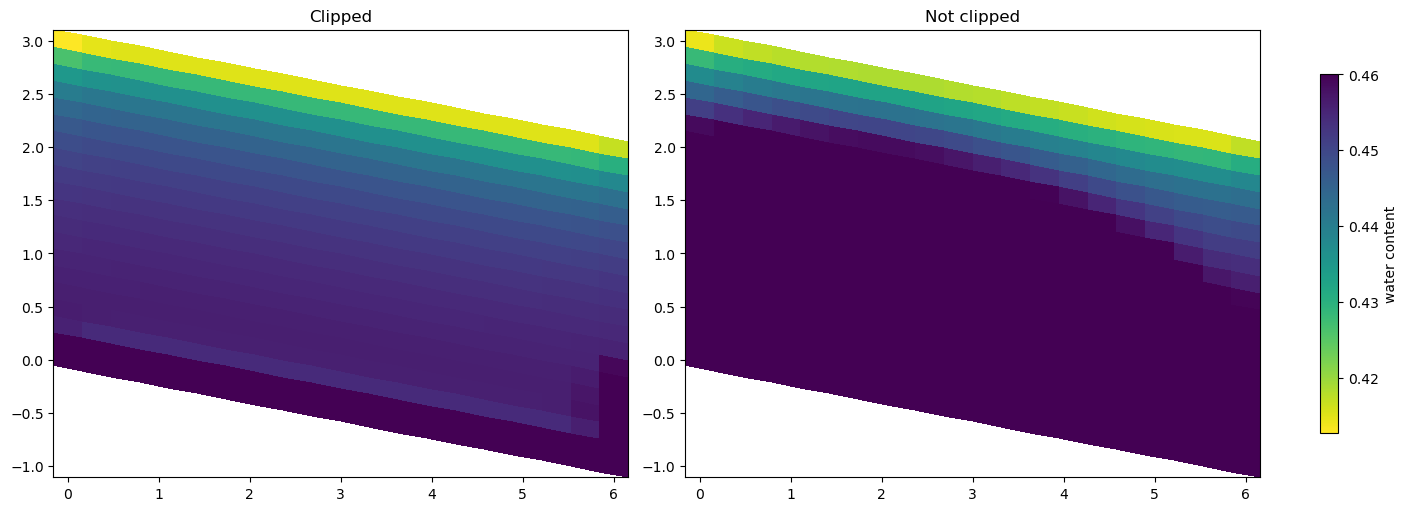

In [9]:
vmin = np.min([t_clipped, t_not])
vmax = np.max([t_clipped, t_not])

fig, ax = plt.subplots(1, 2, layout="constrained", figsize=(14, 5))

pmesh0 = ax[0].pcolormesh(x_grid, z_grid, t_clipped, vmin=vmin, vmax=vmax, cmap="viridis_r")
ax[0].set_title("Clipped")

pmesh1 = ax[1].pcolormesh(x_grid, z_grid, t_not, vmin=vmin, vmax=vmax, cmap="viridis_r")
ax[1].set_title("Not clipped")

#pmesh2 = ax[2].pcolormesh(x_grid, z_grid, t_lump, vmin=vmin, vmax=vmax, cmap="viridis_r")
#ax[2].set_title("Lumped, 16 h")

cbar = fig.colorbar(pmesh1, ax=ax.ravel().tolist(), shrink=0.8)
cbar.set_label("water content")

In [1]:
58429.6875/3600

16.23046875

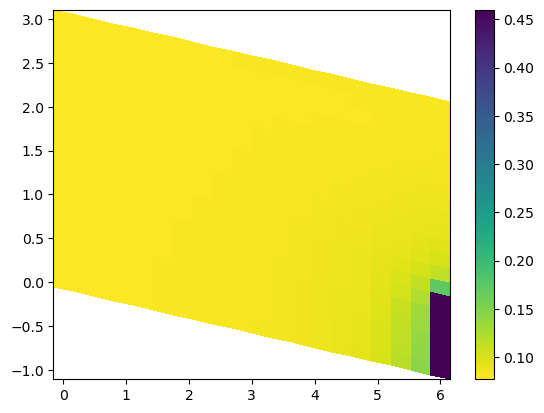

In [14]:
pmesh2 = plt.pcolormesh(x_grid, z_grid, t_lump, cmap="viridis_r")
plt.colorbar(pmesh2)
